# Non-Uniform Radial Poisson Solver:
# Origin Core Concentration Problem ($r \to 0$)

$$
u(r,\theta)
=
(R^2-r^2)
e^{-\alpha \frac{r^2}{R^2}}
\left(\frac{r}{R}\right)^m
\cos\left(m(\theta-\theta_0)\right)
$$

This manufactured Poisson problem models concentrated core physics (e.g., localized laser heating or central charge distributions) near the origin $r = 0$, satisfying homogeneous Dirichlet boundary conditions $u(R, \theta) = 0$.

### Theoretical Principle & Radial Nonuniformity Motivation:
- **Azimuthal Direction (Uniform is Optimal)**: Equispaced sampling in $\theta$ uniquely achieves exact trigonometric interpolation with optimal spectral accuracy and matrix conditioning ($\,\kappa=1\,$). Nonuniform placement in $\theta$ cannot improve accuracy at fixed $N$. For mode $m=1$, $N=32$ resolves the Fourier coefficients to machine precision (zero angular error).
- **Radial Direction (Nonuniform Beats Uniform at Fixed $M$)**: Radial integration is a local 1D polynomial quadrature rule (Trapezoidal/Simpson) combined with recurrences. Local quadrature truncation error is governed by local derivative behavior. When sharp curvature and excitation concentrate near the origin core, uniform radial spacing under-resolves the central region. Concentrating radial nodes near $r=0$ minimizes total quadrature error for a fixed radial point budget $M$ at **zero computational cost overhead**.

In [1]:
import os
import sys
import platform
import psutil
from pathlib import Path

# ---------------------------------------------------------
# Backend & Environment Configuration
# ---------------------------------------------------------
USE_GPU = True  # Set to True for NVIDIA GPU acceleration

# Auto-detect Google Colab & Auto-Sync
IN_COLAB = 'google.colab' in sys.modules or os.environ.get('COLAB_GPU') is not None
if IN_COLAB:
    if not os.path.exists('/content/NUFFTRR_Poisson'):
        os.system('git clone https://github.com/CharliePyle4/NUFFTRR_Poisson.git /content/NUFFTRR_Poisson')
    
    # Fetch and hard reset to latest GitHub commit
    os.system('cd /content/NUFFTRR_Poisson && git fetch origin main && git reset --hard origin/main')
    
    if os.getcwd() != '/content/NUFFTRR_Poisson':
        os.chdir('/content/NUFFTRR_Poisson')
        
    os.system('pip install -r requirements.txt -q')
    if USE_GPU:
        os.system('pip install cufinufft -q')

# Dynamic repository root and helper path resolution
repo_root = str(Path.cwd().resolve())
while repo_root and not os.path.exists(os.path.join(repo_root, 'Poisson_Solver')):
    parent = str(Path(repo_root).parent)
    if parent == repo_root:
        break
    repo_root = parent
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

tests_dir = os.path.join(repo_root, 'Tests', 'paper')
if tests_dir not in sys.path:
    sys.path.insert(0, tests_dir)

# Solver Parameters
# Fixed Angular Grid Resolution (Resolves theta mode to machine precision)
N = 32
num_processors = None    # Number of CPU threads (None = all available cores)

from nonuniform_radial_helpers import *

# Multi-Run Benchmark Timing Configuration
TIME_TRIALS = True  # Set to True to run each test 5 times and record min runtime
NUM_RUNS = 5 if TIME_TRIALS else 1

set_timing_config(time_trials=TIME_TRIALS, num_runs=NUM_RUNS, use_gpu=USE_GPU)

# ---------------------------------------------------------
# System & Hardware Diagnostics Banner
# ---------------------------------------------------------
ram_gb = psutil.virtual_memory().total / (1024 ** 3)
ram_avail_gb = psutil.virtual_memory().available / (1024 ** 3)
cpu_cores_logical = os.cpu_count()
cpu_cores_phys = psutil.cpu_count(logical=False)
cpu_model = platform.processor() or "Generic CPU"
if IN_COLAB and os.path.exists('/proc/cpuinfo'):
    with open('/proc/cpuinfo') as f:
        for line in f:
            if "model name" in line:
                cpu_model = line.split(":", 1)[1].strip()
                break

backend_name = 'GPU (NVIDIA CuPy / cuFINUFFT)' if USE_GPU else 'CPU (Multithreaded FINUFFT)'

print('=' * 75)
print(f'  BENCHMARK ENVIRONMENT SUMMARY')
print('=' * 75)
print(f'  Active Backend  : {backend_name}')
print(f'  Environment     : {"Google Colab" if IN_COLAB else "Local Workstation"} ({platform.system()} {platform.release()})')
print(f'  Host CPU        : {cpu_model}')
print(f'  CPU Cores       : {cpu_cores_phys} Physical / {cpu_cores_logical} Logical Threads')
print(f'  System RAM      : {ram_gb:.1f} GB Total ({ram_avail_gb:.1f} GB Available)')

if USE_GPU:
    try:
        import cupy as cp
        dev = cp.cuda.Device()
        props = cp.cuda.runtime.getDeviceProperties(dev.id)
        gpu_name = props['name'].decode('utf-8') if isinstance(props['name'], bytes) else str(props['name'])
        compute_cap = f"{props['major']}.{props['minor']}"
        free_mem_gb, total_mem_gb = dev.mem_info[0] / (1024**3), dev.mem_info[1] / (1024**3)
        
        print('-' * 75)
        print(f'  GPU Device      : {gpu_name} (Compute Capability: {compute_cap})')
        print(f'  GPU VRAM        : {total_mem_gb:.1f} GB Total ({free_mem_gb:.1f} GB Free)')
        print(f'  CUDA Driver/RT  : {cp.cuda.runtime.runtimeGetVersion()}')
    except Exception as e:
        print(f'  GPU Status      : Warning - GPU query failed: {e}')

print(f'  Time Trials     : {TIME_TRIALS} (Runs = {NUM_RUNS})')
print('=' * 75)


  BENCHMARK ENVIRONMENT SUMMARY
  Active Backend  : GPU (NVIDIA CuPy / cuFINUFFT)
  Environment     : Google Colab (Linux 6.6.122+)
  Host CPU        : Intel(R) Xeon(R) CPU @ 2.20GHz
  CPU Cores       : 6 Physical / 12 Logical Threads
  System RAM      : 53.0 GB Total (51.4 GB Available)
---------------------------------------------------------------------------
  GPU Device      : NVIDIA L4 (Compute Capability: 8.9)
  GPU VRAM        : 22.0 GB Total (21.8 GB Free)
  CUDA Driver/RT  : 12090
  Time Trials     : True (Runs = 5)


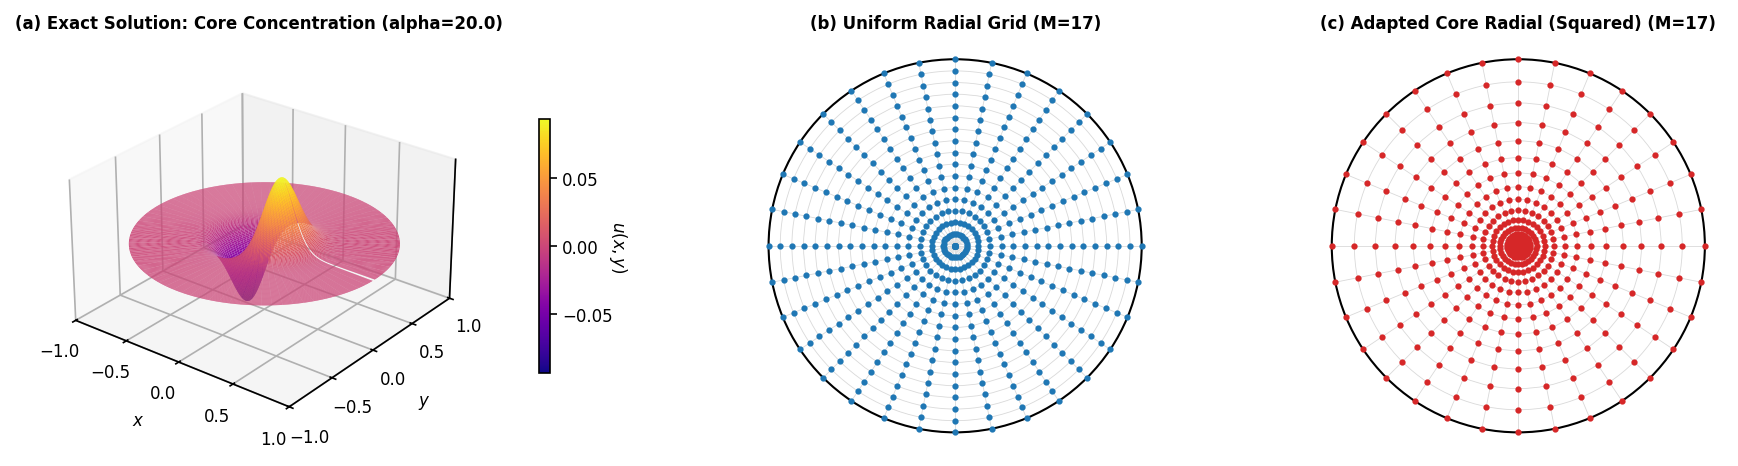

In [2]:
# Problem Setup: Origin Core Concentration (alpha = 20.0, mode = 1)
R = 1.0
mode = 1
alpha_param = 20.0
problem = get_core_concentrated_problem(R=R, mode=mode, alpha_param=alpha_param)

# Journal-style 1 x 3 visualization of solution and radial meshes
plot_solution_and_radial_grids(
    problem=problem,
    N=N,
    M=17,
    primary_kind="squared",
    primary_label="Adapted Core Radial (Squared)"
)


## Radial Refinement ($M$-sweep) Benchmark Study & Performance Profiles

With the angular resolution fixed at $N = 32$, we perform a radial refinement sweep over $M \in \{9, 17, 25, 33, 49, 65, 97, 129, 257\}$.
Tabular benchmarks display **Accuracies first** and **Runtimes last**.

In [3]:
M_dense = [9, 17, 25, 33, 49, 65, 97, 129, 257]
rad_kinds = [
    ("uniform", "Uniform Radial"),
    ("squared", "Adapted Nonuniform (Squared)"),
    ("chebyshev_lobatto", "Chebyshev-Lobatto"),
]

# Execute Radial Grid Sweep for Fixed N = 32
df_fixed_n = run_radial_grid_sweep(problem, N=N, M_values=M_dense, rad_kinds=rad_kinds, quad_rule=2, bc_choice=1, num_processors=num_processors, use_gpu=USE_GPU, time_trials=TIME_TRIALS, num_runs=NUM_RUNS)

# 1. Accuracy Table (Fixed N=32, Varying M) (FIRST)
render_fixed_n_accuracy_table(df_fixed_n, title=f"Table 1: Relative Errors for Fixed N = {N} with Varying Radial Points M")

# 2. Runtime Table (Fixed N=32, Varying M) (LAST)
render_fixed_n_runtime_table(df_fixed_n, title=f"Table 2: Solve Runtimes (ms) for Fixed N = {N} with Varying Radial Points M")


Radial M-sweep (Core Concentration (alpha=20.0)) [GPU]:   0%|          | 0/27 [00:00<?, ?it/s]

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

In [ ]:
# Compute Radial Pointwise Error Profiles at M = 33 for Subplot (b)
M_eval = 33
results_list = []
for kind, label in rad_kinds:
    r_m = generate_custom_radial_grid(M_eval, R=R, kind=kind)
    res = run_radial_benchmark_case(N=N, M=M_eval, r_m=r_m, problem=problem, rad_kind=label, quad_rule=2, bc_choice=1, num_processors=num_processors, use_gpu=USE_GPU, time_trials=TIME_TRIALS, num_runs=NUM_RUNS)
    results_list.append(res)

# Journal-style 1 x 2 Figure: (a) Log-Log M-Refinement Convergence & (b) Semilog-Y Radial Pointwise Error Profiles
plot_combined_radial_convergence_and_profiles(
    df_fixed_n=df_fixed_n,
    results_list=results_list,
    title=f"Origin Core Problem: Radial Convergence & Spatial Error Profiles (N = {N})"
)
